## HWRS 561b Homework #2 {-}
- Assigned: Sunday, 8 February 2026
- Due: Thursday, 19 February 2026 (upload answers in PDF or Jupyter Notebook to D2L)
- Instructor: Bo Guo
- Teaching Assistant: Aldo Andres Tapia Araya
- Semester: Spring 2026


## Question 1.3: BTC shape between two cases ##

3. (7 points) A tracer is injected into a homogeneous sand column of length $L = 1$ m with porewater velocity $V = 0.5$ m/day.
      - Case A: $D = 5 \times 10^{-3}$ m $^2$ /day
      - Case B: $D = 5 \times 10^{-2}$ m $^2$ /day
      
      For each case:
      - Compute $t_a$, $t_d$, and $Pe$.
      - State whether transport is advection-dominated, dispersion-dominated, or transitional (i.e., advection and dispersion are comparable).
      - Predict qualitatively and sketch how the breakthrough curve shape would differ between the two cases. 

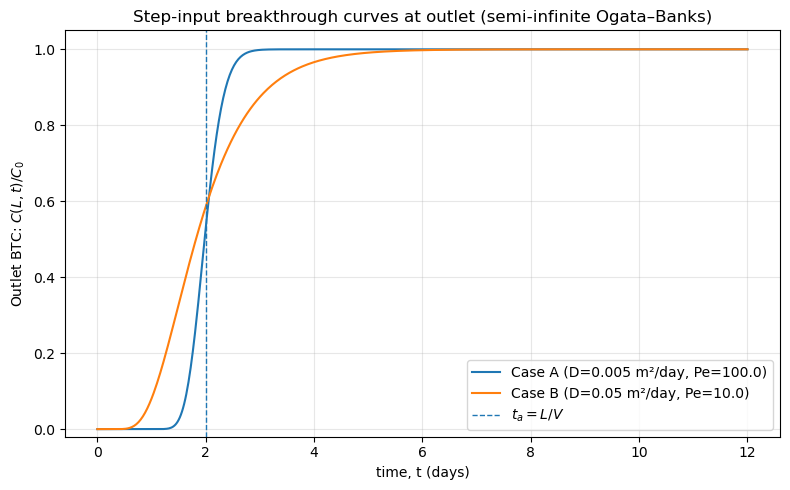

=== Computed metrics ===

Case A
  D  = 5.000e-03 m^2/day
  t_a = L/V   = 2.000 days
  t_d = L^2/D = 200.000 days
  Pe  = VL/D  = 100.000

Case B
  D  = 5.000e-02 m^2/day
  t_a = L/V   = 2.000 days
  t_d = L^2/D = 20.000 days
  Pe  = VL/D  = 10.000


In [1]:
# PROBLEM 1.3

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

# Given problem parameters
L = 1.0        # m
V = 0.5        # m/day (porewater velocity)

cases = {
    "Case A": {"D": 5e-3},   # m^2/day
    "Case B": {"D": 5e-2},   # m^2/day
}
# Time scales + Peclet number
def advective_time(L, V):
    return L / V

def dispersive_time(L, D):
    return L**2 / D

def peclet(L, V, D):
    return V * L / D

# Ogata–Banks step-input solution (semi-infinite domain)
# C/C0 at position x, time t (t>0)
def C_over_C0_step_ogata_banks(x, t, V, D):
    """
    Semi-infinite domain, step change at inlet x=0:
      C(0,t)=C0 for t>0, C(x,0)=0, C(x->inf,t) bounded.

    Returns C(x,t)/C0.
    """
    t = np.asarray(t)
    out = np.zeros_like(t, dtype=float)

    # Avoid division by zero at t=0
    mask = t > 0
    tm = t[mask]

    term1 = 0.5 * erfc((x - V * tm) / (2.0 * np.sqrt(D * tm)))
    term2 = 0.5 * np.exp(V * x / D) * erfc((x + V * tm) / (2.0 * np.sqrt(D * tm)))
    out[mask] = term1 + term2
    return out

# Compute metrics + plot BTCs at outlet x=L
ta = advective_time(L, V)

plt.figure(figsize=(8, 5))

for name, p in cases.items():
    D = p["D"]
    td = dispersive_time(L, D)
    Pe = peclet(L, V, D)

    # Store for printing
    p["ta"] = ta
    p["td"] = td
    p["Pe"] = Pe

    # Choose a time window that shows the curve well:
    # go out to a few advective times (works for both cases)
    t = np.linspace(0, 6 * ta, 600)  # days

    CLC0 = C_over_C0_step_ogata_banks(L, t, V, D)

    plt.plot(t, CLC0, label=f"{name} (D={D:g} m²/day, Pe={Pe:.1f})")

# Plot formatting
plt.axvline(ta, linestyle="--", linewidth=1, label=r"$t_a = L/V$")
plt.xlabel("time, t (days)")
plt.ylabel(r"Outlet BTC: $C(L,t)/C_0$")
plt.title("Step-input breakthrough curves at outlet (semi-infinite Ogata–Banks)")
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print results neatly
print("=== Computed metrics ===")
for name, p in cases.items():
    print(f"\n{name}")
    print(f"  D  = {p['D']:.3e} m^2/day")
    print(f"  t_a = L/V   = {p['ta']:.3f} days")
    print(f"  t_d = L^2/D = {p['td']:.3f} days")
    print(f"  Pe  = VL/D  = {p['Pe']:.3f}")


In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from math import erfc


## Question 2: Part 3 ##

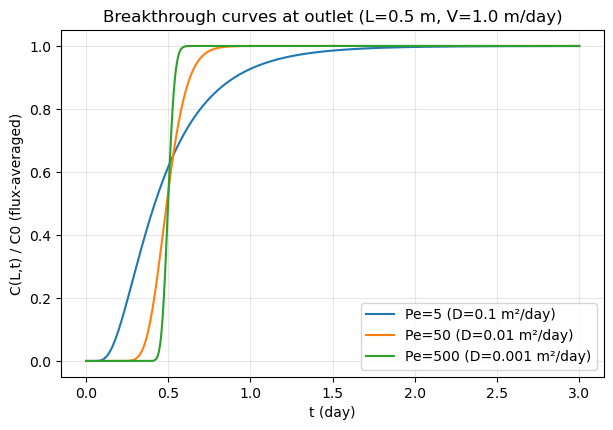

Advective time t_a = L/V = 0.500 day

Pe=  5: D=0.1000 m²/day, t_d=L²/D=2.50 day, check Pe=V L / D=5
Pe= 50: D=0.0100 m²/day, t_d=L²/D=25.00 day, check Pe=V L / D=50
Pe=500: D=0.0010 m²/day, t_d=L²/D=250.00 day, check Pe=V L / D=500


In [3]:
# --- Given/assumed ---
L = 0.5        # m (given)
V = 1.0        # m/day (chosen)
Pe_list = [5, 50, 500]

# Choose D to match each Peclet number: Pe = V L / D  =>  D = V L / Pe
D_list = [V * L / Pe for Pe in Pe_list]  # m^2/day


# --- Helpers ---
def erfc_vec(z):
    """Vectorized complementary error function."""
    return np.vectorize(math.erfc)(z)


def Cf_over_C0(t, x, V, D):
    """
    Flux-averaged (flux-based) concentration for continuous injection (3rd-type BC),
    as used in the class slide:
      Cf/C0 = 1/2 [ erfc((x - V t)/(2 sqrt(D t))) + exp(V x / D) * erfc((x + V t)/(2 sqrt(D t))) ]
    """
    denom = 2.0 * np.sqrt(D * t)
    term1 = erfc_vec((x - V * t) / denom)
    term2 = np.exp(V * x / D) * erfc_vec((x + V * t) / denom)
    return 0.5 * (term1 + term2)


# --- Time grid (avoid t=0 to prevent divide-by-zero) ---
t_a = L / V
t_max = 6 * t_a              # plot out to 6 advective times (adjust if you want)
t = np.linspace(1e-4, t_max, 800)

# --- Plot BTCs at the outlet x = L ---
plt.figure(figsize=(7, 4.5))

for Pe, D in zip(Pe_list, D_list):
    y = Cf_over_C0(t, x=L, V=V, D=D)
    plt.plot(t, y, label=f"Pe={Pe} (D={D:.3g} m²/day)")

plt.xlabel("t (day)")
plt.ylabel("C(L,t) / C0 (flux-averaged)")
plt.title(f"Breakthrough curves at outlet (L={L} m, V={V} m/day)")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --- Optional: print D and time scales for each case ---
print(f"Advective time t_a = L/V = {t_a:.3f} day\n")
for Pe, D in zip(Pe_list, D_list):
    t_d = L**2 / D
    print(f"Pe={Pe:>3}: D={D:.4f} m²/day, t_d=L²/D={t_d:.2f} day, check Pe=V L / D={V*L/D:.0f}")


## Question 3: Part 2 ##

C(x,t)/C0 =

 0.5*erfc((x - V*t)/(2*sqrt(D*t)))
+0.5*exp(V*x/D)*erfc((x + V*t)/(2*sqrt(D*t)))

-0.5*erfc((x - V*(t - t0))/(2*sqrt(D*(t - t0))))
-0.5*exp(V*x/D)*erfc((x + V*(t - t0))/(2*sqrt(D*(t - t0))))

+0.5*erfc((x - V*(t - T))/(2*sqrt(D*(t - T))))
+0.5*exp(V*x/D)*erfc((x + V*(t - T))/(2*sqrt(D*(t - T))))

-0.5*erfc((x - V*(t - T - t0))/(2*sqrt(D*(t - T - t0))))
-0.5*exp(V*x/D)*erfc((x + V*(t - T - t0))/(2*sqrt(D*(t - T - t0))))

## Question 3: Part 3 ##

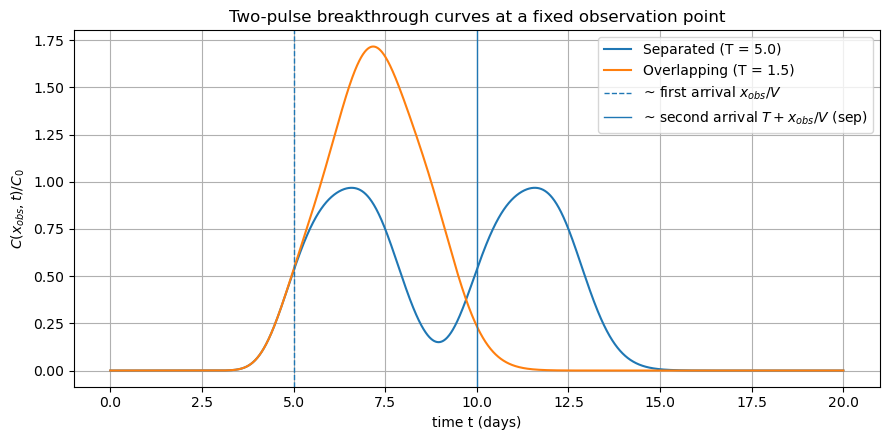

In [4]:
# -----------------------------
# Two-pulse breakthrough curve (BTC) at x = x_obs
# Uses the semi-infinite "step-change" solution F(x,t) and superposition:
#   pulse(t_on -> t_off) = F(x,t-t_on) - F(x,t-t_off)
#   two pulses = pulse1 + pulse2
# -----------------------------

def F_step(x, t, V, D, C0):
    """
    Step-change (continuous injection starting at t=0) solution at location x.
    Returns concentration C(x,t) for t>0, else 0.

    C/C0 = 0.5*erfc((x - V t)/(2 sqrt(D t))) + 0.5*exp(Vx/D)*erfc((x + V t)/(2 sqrt(D t)))
    """
    t = np.asarray(t, dtype=float)
    C = np.zeros_like(t)

    mask = t > 0
    tm = t[mask]
    arg1 = (x - V * tm) / (2.0 * np.sqrt(D * tm))
    arg2 = (x + V * tm) / (2.0 * np.sqrt(D * tm))

    # vectorize erfc from math for numpy arrays
    erfc_vec = np.vectorize(erfc)

    C[mask] = C0 * (
        0.5 * erfc_vec(arg1) +
        0.5 * np.exp((V * x) / D) * erfc_vec(arg2)
    )
    return C

def pulse_from_step(x, t, V, D, C0, t_on, t_off):
    """Pulse = step starting at t_on minus step starting at t_off."""
    return F_step(x, t - t_on, V, D, C0) - F_step(x, t - t_off, V, D, C0)

def two_pulse_BTC(x_obs, t, V, D, C0, t0, T):
    """Pulse 1: [0, t0], Pulse 2: [T, T+t0]."""
    C1 = pulse_from_step(x_obs, t, V, D, C0, t_on=0.0, t_off=t0)
    C2 = pulse_from_step(x_obs, t, V, D, C0, t_on=T,   t_off=T + t0)
    return C1 + C2

# -----------------------------
# Choose a sample scenario
# -----------------------------
C0   = 1.0      # inlet concentration during pulses (arbitrary units)
V    = 1.0      # velocity (m/day)
D    = 0.05     # dispersion (m^2/day)
xobs = 5.0      # observation location (m)
t0   = 3      # pulse duration (day)

# Make TWO cases to illustrate Step C:
# 1) separated pulses (big T)
# 2) overlapping pulses (small T)
T_separated = 5.0
T_overlap   = 1.5

tmax = 20.0
t = np.linspace(0, tmax, 2000)

C_sep = two_pulse_BTC(xobs, t, V, D, C0, t0, T_separated)
C_ovl = two_pulse_BTC(xobs, t, V, D, C0, t0, T_overlap)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9, 4.5))
plt.plot(t, C_sep / C0, label=f"Separated (T = {T_separated})")
plt.plot(t, C_ovl / C0, label=f"Overlapping (T = {T_overlap})")

# Mark approximate advective arrival times for intuition
t_arr1 = xobs / V
plt.axvline(t_arr1, linestyle="--", linewidth=1, label=r"~ first arrival $x_{obs}/V$")
plt.axvline(T_separated + t_arr1, linewidth=1, label=r"~ second arrival $T + x_{obs}/V$ (sep)")

plt.xlabel("time t (days)")
plt.ylabel(r"$C(x_{obs},t)/C_0$")
plt.title("Two-pulse breakthrough curves at a fixed observation point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Tip:
# - Increase D -> broader tails -> more overlap.
# - Decrease T -> more overlap.
# - Increase xobs -> more spreading before observation (often more overlap).
# -----------------------------


## Question 4: Part 2 ##

=== Solute A (Kd=0) ===
R_A = 1
Veff_A = 0.4 m/day
Deff_A = 0.02 m^2/day

=== Solute B (Kd=0.8 L/kg) ===
R_B = 4.77143
Veff_B = 0.0838323 m/day
Deff_B = 0.00419162 m^2/day

At x=L=0.5 m: t50 (A) ~ 1.14 days,  t50 (B) ~ 5.43 days
Time-delay factor t50_B/t50_A ~ 4.77


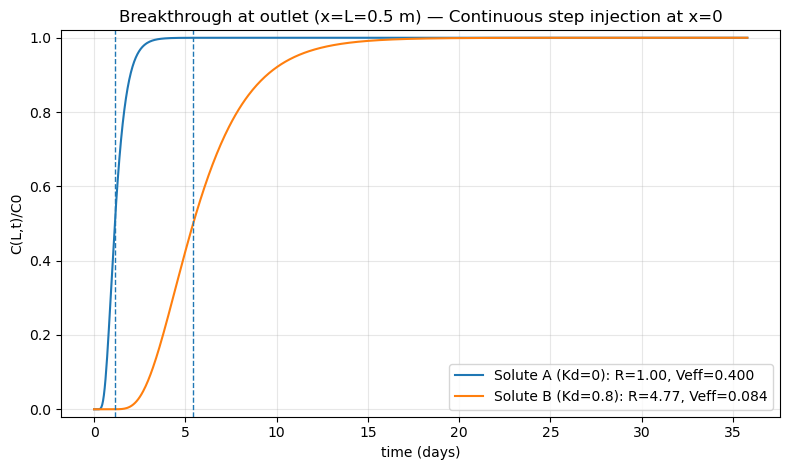

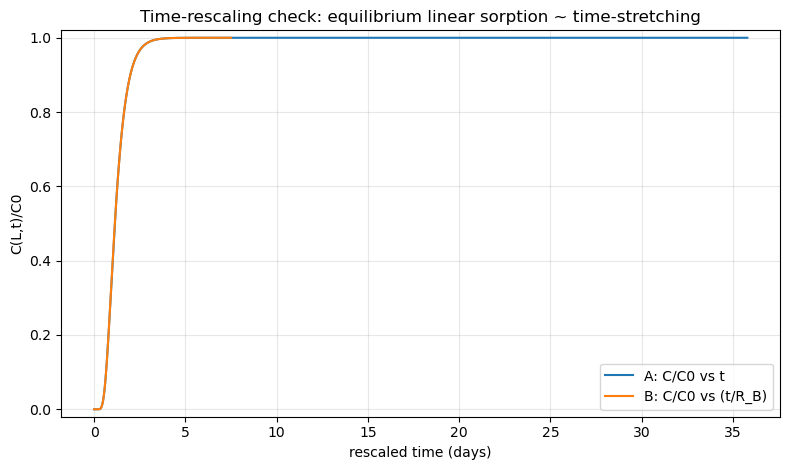

In [5]:
from scipy.special import erfc

# -----------------------------
# Problem 4, Part 2 parameters
# -----------------------------
phi = 0.35
rho_b_g_cm3 = 1.65          # g/cm^3
rho_b = rho_b_g_cm3         # = 1.65 kg/L (so it matches Kd in L/kg)
V = 0.4                     # m/day (pore water velocity)
D = 0.02                    # m^2/day (dispersion coefficient)
C0 = 1.0                    # mg/L (injected concentration)

Kd_A = 0.0                  # L/kg
Kd_B = 0.8                  # L/kg

# Choose a column length to evaluate breakthrough at x = L
L = 0.5                     # m 

# -----------------------------
# Retardation + effective params
# -----------------------------
def retardation(phi, rho_b, Kd):
    return 1.0 + (rho_b * Kd) / phi

R_A = retardation(phi, rho_b, Kd_A)
R_B = retardation(phi, rho_b, Kd_B)

Veff_A = V / R_A
Veff_B = V / R_B

# For linear equilibrium sorption, divide ADE by R:
# dC/dt + (V/R) dC/dx - (D/R) d2C/dx2 = 0  => use D_eff = D/R
Deff_A = D / R_A
Deff_B = D / R_B

print("=== Solute A (Kd=0) ===")
print(f"R_A = {R_A:.6g}")
print(f"Veff_A = {Veff_A:.6g} m/day")
print(f"Deff_A = {Deff_A:.6g} m^2/day\n")

print("=== Solute B (Kd=0.8 L/kg) ===")
print(f"R_B = {R_B:.6g}")
print(f"Veff_B = {Veff_B:.6g} m/day")
print(f"Deff_B = {Deff_B:.6g} m^2/day\n")

# -----------------------------
# Ogata–Banks step-input solution (semi-infinite, constant C0 at x=0)
# Breakthrough at x = L
# -----------------------------
def C_over_C0_step_input(x, t, v, D):
    """
    Semi-infinite solution for step input boundary:
      C(0,t) = C0 for t>0,  C(x,0)=0,  x>0
    Returns C/C0 at position x for array t.
    """
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)

    # avoid division by zero at t=0
    mask = t > 0
    tm = t[mask]

    term1 = 0.5 * erfc((x - v*tm) / (2.0*np.sqrt(D*tm)))
    term2 = 0.5 * np.exp(v*x/D) * erfc((x + v*tm) / (2.0*np.sqrt(D*tm)))
    out[mask] = term1 + term2

    # numerical safety
    out = np.clip(out, 0.0, 1.0)
    return out

# -----------------------------
# Time grid
# -----------------------------
# Choose tmax so both solutes reach near steady (C/C0 ~ 1) at outlet
tadv_A = L / Veff_A
tadv_B = L / Veff_B
tmax = 6 * tadv_B  # long enough for B to break through clearly
t = np.linspace(0, tmax, 800)

# Compute BTCs at outlet x=L
btc_A = C_over_C0_step_input(L, t, Veff_A, Deff_A)
btc_B = C_over_C0_step_input(L, t, Veff_B, Deff_B)

# -----------------------------
# Simple arrival-time markers
# -----------------------------
def t_at_fraction(t, y, frac=0.5):
    """Return approximate time when y(t) first reaches frac (linear interp)."""
    idx = np.where(y >= frac)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    if i == 0:
        return t[0]
    # linear interpolation between i-1 and i
    t0, t1 = t[i-1], t[i]
    y0, y1 = y[i-1], y[i]
    return t0 + (frac - y0) * (t1 - t0) / (y1 - y0 + 1e-30)

t50_A = t_at_fraction(t, btc_A, 0.5)
t50_B = t_at_fraction(t, btc_B, 0.5)

print(f"At x=L={L} m: t50 (A) ~ {t50_A:.3g} days,  t50 (B) ~ {t50_B:.3g} days")
if np.isfinite(t50_A) and np.isfinite(t50_B):
    print(f"Time-delay factor t50_B/t50_A ~ {t50_B/t50_A:.3g}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 4.8))
plt.plot(t, btc_A, label=f"Solute A (Kd=0): R={R_A:.2f}, Veff={Veff_A:.3f}")
plt.plot(t, btc_B, label=f"Solute B (Kd=0.8): R={R_B:.2f}, Veff={Veff_B:.3f}")

# mark 50% arrival times
plt.axvline(t50_A, linestyle="--", linewidth=1)
plt.axvline(t50_B, linestyle="--", linewidth=1)

plt.xlabel("time (days)")
plt.ylabel("C(L,t)/C0")
plt.title(f"Breakthrough at outlet (x=L={L} m) — Continuous step injection at x=0")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# OPTIONAL: show "shape unchanged" by time-rescaling
# (If you plot B vs. (t/R_B), it should line up closely with A.)
# -----------------------------
plt.figure(figsize=(8, 4.8))
plt.plot(t, btc_A, label="A: C/C0 vs t")
plt.plot(t / R_B, btc_B, label="B: C/C0 vs (t/R_B)")
plt.xlabel("rescaled time (days)")
plt.ylabel("C(L,t)/C0")
plt.title("Time-rescaling check: equilibrium linear sorption ~ time-stretching")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Problem 4: Part 3 ##

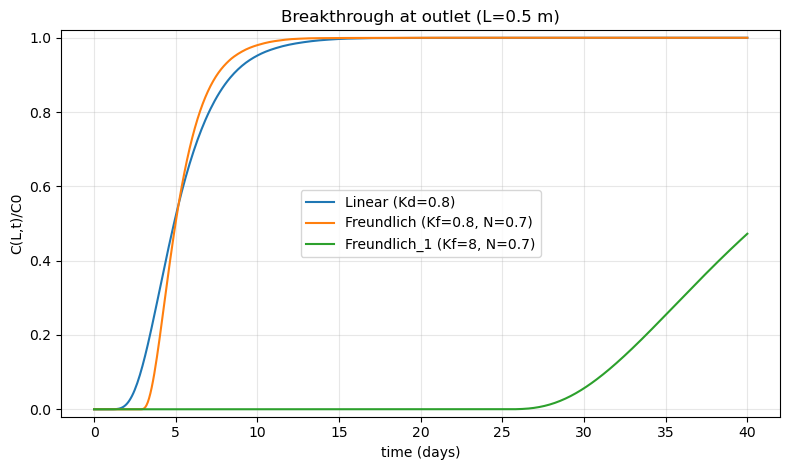

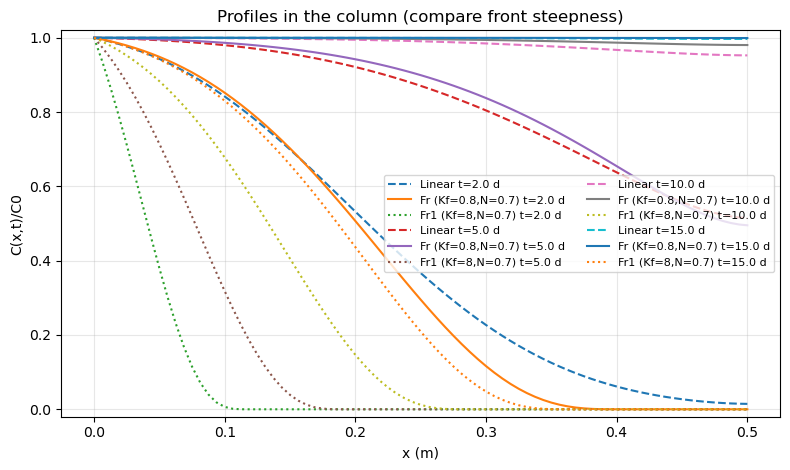

Solver success (linear):      True | The solver successfully reached the end of the integration interval.
Solver success (Freundlich):  True | The solver successfully reached the end of the integration interval.
Solver success (Freundlich1): True | The solver successfully reached the end of the integration interval.


In [6]:
# ============================================================
# DROP-IN CELL: Freundlich isotherm "playground" (fixed)
# Solves: Linear + Freundlich (Kf,N) + Freundlich_1 (Kf_1,N_1)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import diags

# ----------------------------
# Parameters (edit if you want)
# ----------------------------
phi = 0.35
rho_b = 1.65            # treat 1.65 g/cm^3 as 1.65 kg/L
V = 0.4                 # m/day
D = 0.02                # m^2/day
C0 = 1.0                # mg/L (step injection at inlet)
L = 0.5                 # m (column length / outlet location)

# Linear sorption comparison
Kd_linear = 0.8         # L/kg

# Freundlich sorption (given)
Kf = 0.8
N = 0.7

# Freundlich sorption "play with these"
Kf_1 = 8
N_1  = 0.7

# Numerics
Nx = 81
t_end = 40.0
t_eval = np.linspace(0, t_end, 500)

# ----------------------------
# Grid / unknown indexing
# ----------------------------
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]

idx_unknown = np.arange(1, Nx)   # unknowns at nodes 1..Nx-1
Nunk = len(idx_unknown)

# Jacobian sparsity (tri-diagonal)
band = np.ones(Nunk)
jac_sparsity = diags([band, band, band], offsets=[-1, 0, 1],
                     shape=(Nunk, Nunk), format="csc")

# ----------------------------
# Retardation factors
# ----------------------------
def R_linear(C):
    return 1.0 + (rho_b/phi) * Kd_linear

def make_R_freundlich(Kf_use, N_use, C_floor_min=1e-6):
    """
    Returns a function R(C) for Freundlich Cs=Kf*C^N
    R(C) = 1 + (rho_b/phi) * dCs/dC
         = 1 + (rho_b/phi) * (Kf*N*C^(N-1))
    """
    def R(C):
        C_floor = np.maximum(C, C_floor_min)
        dCs_dC = Kf_use * N_use * (C_floor ** (N_use - 1.0))
        return 1.0 + (rho_b/phi) * dCs_dC
    return R

R_freundlich   = make_R_freundlich(Kf,   N)
R_freundlich_1 = make_R_freundlich(Kf_1, N_1)

# ----------------------------
# RHS builder for method-of-lines
# ----------------------------
def rhs_factory(R_of_C):
    """
    dC/dt = (-V dC/dx + D d2C/dx2) / R(C)
    Spatial discretization:
      - upwind advection (assumes V>0)
      - central dispersion
      - inlet Dirichlet: C(0,t)=C0
      - outlet Neumann: dC/dx=0
    """
    def rhs(t, C_unknown):
        C_full = np.empty(Nx, dtype=float)
        C_full[0] = C0
        C_full[1:] = C_unknown

        # Neumann at outlet: ghost = last node
        C_ghost = C_full[-1]

        dCdt = np.zeros_like(C_unknown)

        for k, i in enumerate(idx_unknown):
            Ci = C_full[i]

            # upwind advection
            dCdx = (C_full[i] - C_full[i-1]) / dx

            # dispersion (central second derivative)
            Cip1 = C_ghost if (i == Nx - 1) else C_full[i+1]
            Cim1 = C_full[i-1]
            d2Cdx2 = (Cip1 - 2.0*Ci + Cim1) / (dx*dx)

            Ri = R_of_C(Ci)
            dCdt[k] = (-V * dCdx + D * d2Cdx2) / Ri

        return dCdt
    return rhs

# ----------------------------
# Solve three cases
# ----------------------------
C_init_unknown = np.zeros(Nunk)

rhs_lin   = rhs_factory(R_linear)
rhs_fr    = rhs_factory(R_freundlich)
rhs_fr_1  = rhs_factory(R_freundlich_1)

sol_lin  = solve_ivp(rhs_lin,  (0, t_end), C_init_unknown, t_eval=t_eval,
                     method="BDF", jac_sparsity=jac_sparsity)
sol_fr   = solve_ivp(rhs_fr,   (0, t_end), C_init_unknown, t_eval=t_eval,
                     method="BDF", jac_sparsity=jac_sparsity)
sol_fr_1 = solve_ivp(rhs_fr_1, (0, t_end), C_init_unknown, t_eval=t_eval,
                     method="BDF", jac_sparsity=jac_sparsity)

t = sol_lin.t

# Outlet BTC (node Nx-1 is last unknown)
btc_lin  = sol_lin.y[-1, :]  / C0
btc_fr   = sol_fr.y[-1, :]   / C0
btc_fr_1 = sol_fr_1.y[-1, :] / C0

# ----------------------------
# Plot BTCs
# ----------------------------
plt.figure(figsize=(8, 4.8))
plt.plot(t, btc_lin,  label=f"Linear (Kd={Kd_linear})")
plt.plot(t, btc_fr,   label=f"Freundlich (Kf={Kf}, N={N})")
plt.plot(t, btc_fr_1, label=f"Freundlich_1 (Kf={Kf_1}, N={N_1})")
plt.xlabel("time (days)")
plt.ylabel("C(L,t)/C0")
plt.title(f"Breakthrough at outlet (L={L} m)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Plot internal profiles (optional but very useful)
# ----------------------------
times_to_show = [2, 5, 10, 15]
plt.figure(figsize=(8, 4.8))

for tt in times_to_show:
    j = np.argmin(np.abs(t - tt))

    C_lin_full  = np.empty(Nx); C_lin_full[0]  = C0; C_lin_full[1:]  = sol_lin.y[:, j]
    C_fr_full   = np.empty(Nx); C_fr_full[0]   = C0; C_fr_full[1:]   = sol_fr.y[:, j]
    C_fr1_full  = np.empty(Nx); C_fr1_full[0]  = C0; C_fr1_full[1:]  = sol_fr_1.y[:, j]

    plt.plot(x, C_lin_full/C0,  "--", label=f"Linear t={t[j]:.1f} d")
    plt.plot(x, C_fr_full/C0,   "-",  label=f"Fr (Kf={Kf},N={N}) t={t[j]:.1f} d")
    plt.plot(x, C_fr1_full/C0,  ":",  label=f"Fr1 (Kf={Kf_1},N={N_1}) t={t[j]:.1f} d")

plt.xlabel("x (m)")
plt.ylabel("C(x,t)/C0")
plt.title("Profiles in the column (compare front steepness)")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(ncols=2, fontsize=8)
plt.tight_layout()
plt.show()

# ----------------------------
# Quick sanity printouts
# ----------------------------
print("Solver success (linear):     ", sol_lin.success,  "|", sol_lin.message)
print("Solver success (Freundlich): ", sol_fr.success,   "|", sol_fr.message)
print("Solver success (Freundlich1):", sol_fr_1.success, "|", sol_fr_1.message)


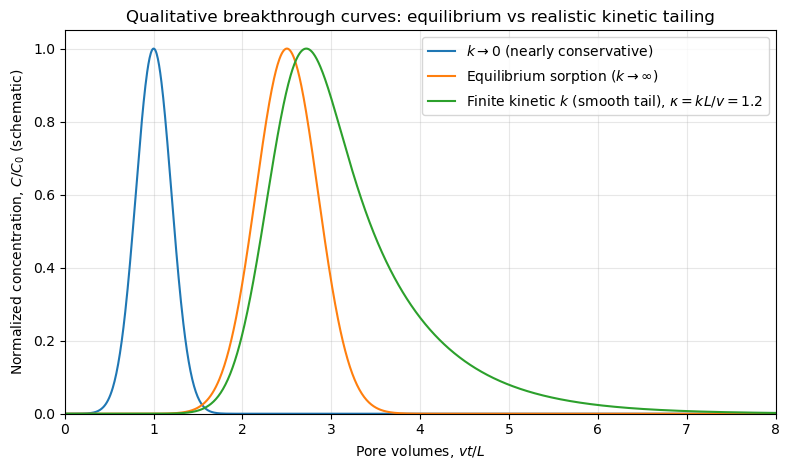

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(pv, mu, sigma, amp=1.0):
    return amp * np.exp(-0.5 * ((pv - mu) / sigma) ** 2)

def kinetic_convolution(pv, C_eq, tau_k_pv, f=0.7):
    """
    Physically-motivated smooth kinetic BTC:
      C_kin = (1-f)*C_eq + f * (C_eq convolved with exponential kernel)

    pv         : array of pore volumes (vt/L)
    C_eq       : "equilibrium/instantaneous" BTC evaluated on pv
    tau_k_pv   : kinetic timescale in pore-volume units (PV)
    f          : fraction experiencing kinetic delay (0..1)
    """
    dpv = pv[1] - pv[0]

    # Exponential waiting-time kernel for first-order process
    kernel = (1.0 / tau_k_pv) * np.exp(-pv / tau_k_pv)

    # Discrete convolution approximates integral with a dpv factor
    conv = np.convolve(C_eq, kernel, mode="full")[:len(pv)] * dpv

    C_kin = (1 - f) * C_eq + f * conv
    return C_kin

# ----- x-axis in pore volumes -----
pv = np.linspace(0, 8, 1200)

# ----- reference curves -----
# k -> 0 : conservative-like
C_k0 = gaussian(pv, mu=1.0, sigma=0.20, amp=1.0)

# equilibrium sorption (≈ k -> infinity): delayed by "R"
R = 2.5
C_eq = gaussian(pv, mu=R, sigma=0.35, amp=1.0)

# ----- physically realistic kinetic curve via convolution -----
# Choose a dimensionless kinetic rate kappa = kL/v
# Small kappa = slow kinetics = longer tail; large kappa = fast kinetics ~ equilibrium
kappa = 1.2                 # try 0.3, 1.2, 5.0 to see the effect
tau_k_pv = 1.0 / kappa      # kinetic timescale in pore volumes
f = 0.8                     # fraction subject to kinetic delay (0..1)

C_kin = kinetic_convolution(pv, C_eq, tau_k_pv=tau_k_pv, f=f)

# ----- normalize for easy comparison (optional) -----
def rescale_to_one(y):
    m = y.max()
    return y / m if m > 0 else y

C_k0 = rescale_to_one(C_k0)
C_eq = rescale_to_one(C_eq)
C_kin = rescale_to_one(C_kin)

# ----- plot -----
plt.figure(figsize=(8, 4.8))
plt.plot(pv, C_k0, label=r"$k \to 0$ (nearly conservative)")
plt.plot(pv, C_eq, label=r"Equilibrium sorption ($k \to \infty$)")
plt.plot(pv, C_kin, label=fr"Finite kinetic $k$ (smooth tail), $\kappa=kL/v={kappa}$")

plt.xlabel(r"Pore volumes, $vt/L$")
plt.ylabel(r"Normalized concentration, $C/C_0$ (schematic)")
plt.title("Qualitative breakthrough curves: equilibrium vs realistic kinetic tailing")
plt.xlim(0, 8)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
